# Windowed feature selection — `d`-day lookback, `h`-day horizon

Selects features for a **sequence model**: one training sample is a `(d, n)` matrix
of days `N-d+1 … N`, and the label is the return over `[N, N+h]`.

This run: **VCB, `d = 20`, `h ∈ {5, 10}`**, over
`unified_schema_vcb.pool__basic ⋈ pool__targets`.

The un-windowed baseline is [feature_selection.ipynb](feature_selection.ipynb)
(`d = 1`); everything here is the same package with `lookback` set.

## One training sample

| | |
|---|---|
| **input** | rows `N-d+1 … N` of the feature panel — a `(d, n)` matrix |
| **output** | `y_N` = `pool__targets.return_{h}day[N]` = `close[N+h] / close[N] − 1` |
| **the label lives on row `N`** | it already looks forward; nothing is shifted here |

⚠️ A tree takes a vector, not a matrix, so the selector reduces each channel's
window to **six summary statistics** — `last, mean, slope, sd, min, max`. That
turns `(4211, 20, 27)` into a `(4211, 162)` design matrix. `last` is the raw value
at day `N`, so `d = 1` reduces to the un-windowed selector exactly.

The alternative — one column per `(feature, lag)`, which is what
`unified_schema_creator.ipynb` did — is 540 columns here and **18,000** on
`pool__ta`, and it answers *which lag matters* when the model reads every lag
anyway. The six stats answer the question that is actually useful: does this
channel matter through its **level**, its **direction**, or its **dispersion**?

## ⚠️ The purge gap is `d + h − 1`, not `h`

Training sample `M` and test sample `N` share nothing only if `M + h < N − d + 1`.
At `d = 20, h = 5` that is a **24-row gap**; purging only `h = 5` would leave 19
rows of the test sample's own input window inside the training set. This is the
easiest way to make a windowed model look predictive when it is not, and it gets
worse as `d` grows.

## ⚠️ The unit of selection is a CHANNEL

The model consumes all `d` days of a feature or none of them, so scoring,
redundancy pruning and validation all happen at channel level. Selecting
`close_adjust` means the model gets its level, its slope and its dispersion —
which is what a sequence model fed that channel would see too.

## Imports & theme

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import pandas as pd

from feature_selection import gpu, plots, windows
from feature_selection.selector import FeatureSelector, PurgedWalkForward
from feature_selection.unified_reader import UnifiedSchemaReader

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
plots.use_theme()

available, why = gpu.cuda_available()
print(f"CUDA usable: {available}" + (f" — {why}" if why else ""))

CUDA usable: True


## Parameters

In [2]:
TICKER = "VCB"
POOLS = ["pool__basic", "pool__targets"]

LOOKBACK = 20                       # d — window length, in trading days
HORIZONS = [5, 10]                  # h — one run per horizon
WINDOW_STATS = windows.WINDOW_STATS  # ("last", "mean", "slope", "sd", "min", "max")

MAX_FEATURES = 12        # cap on kept CHANNELS, applied after the redundancy prune
CORR_THRESHOLD = 0.9     # |Spearman| above which the lower-ranked channel is dropped
N_SPLITS = 5             # walk-forward folds
MIN_TRAIN = 500          # samples in the first fold's training window

DEVICE = "auto"          # see gpu.py — "auto" goes to the GPU once the pool is wide
SUBSAMPLE = 0.8          # ⚠️ set both to 1.0 for a device-reproducible run
COLSAMPLE_BYTREE = 0.8

IDENTITY = ["exchange", "ticker"]
GICS = [
    "sector", "sector_code", "industry_group", "industry_group_code",
    "industry", "industry_code", "sub_industry", "sub_industry_code",
]

## Read & join

`pool__targets` now carries **one column per horizon** —
`DataPreprocessor.UNIFIED_TARGET_HORIZONS = (5, 10)`, so the label definition
lives in one place and both horizons sit on one calendar. Note the tails differ:
`return_5day` loses 5 rows, `return_10day` loses 10.

In [3]:
reader = UnifiedSchemaReader(TICKER).connect()
panel = reader.join(POOLS)
reader.close()

target_cols = [f"return_{h}day" for h in HORIZONS]
print(f"panel: {panel.shape[0]:,} rows x {panel.shape[1]} columns "
      f"({panel['date'].min():%Y-%m-%d} -> {panel['date'].max():%Y-%m-%d})")
labels = pd.DataFrame({
    "target": target_cols,
    "labelled": [int(panel[c].notna().sum()) for c in target_cols],
    "unlabelled_tail": [int(panel[c].isna().sum()) for c in target_cols],
    "mean": [round(float(panel[c].mean()), 5) for c in target_cols],
    "sd": [round(float(panel[c].std()), 5) for c in target_cols],
})
labels

panel: 4,235 rows x 40 columns (2009-06-30 -> 2026-06-25)


,target,labelled,unlabelled_tail,mean,sd
0,return_5day,4230,5,0.00319,0.04295
1,return_10day,4225,10,0.00646,0.05983


## The sample arithmetic

Usable samples are `L − d − h + 1`, and the purge gap is `d + h − 1`. Both depend
on `h`, so the two horizons do **not** have the same sample count — which is why
each target's own tail is dropped rather than a shared one.

In [4]:
arithmetic = pd.DataFrame([
    {
        "horizon_h": h,
        "lookback_d": LOOKBACK,
        "panel_rows_L": len(panel),
        "usable_samples": windows.usable_sample_count(len(panel), LOOKBACK, h),
        "purge_gap_rows": PurgedWalkForward(horizon=h, lookback=LOOKBACK).gap,
        "gap_if_lookback_ignored": h,
    }
    for h in HORIZONS
])
arithmetic

,horizon_h,lookback_d,panel_rows_L,usable_samples,purge_gap_rows,gap_if_lookback_ignored
0,5,20,4235,4211,24,5
1,10,20,4235,4206,29,10


## Run both horizons

Each run excludes the *other* horizon's label — a target column left in the
feature pool is a perfect predictor of itself and would dominate every ranking.

In [5]:
results = {}
for h in HORIZONS:
    target = f"return_{h}day"
    other_targets = [c for c in target_cols if c != target]
    results[f"h={h}"] = FeatureSelector(
        panel=panel,
        target=target,
        exclude=IDENTITY + GICS + other_targets,
        max_features=MAX_FEATURES,
        corr_threshold=CORR_THRESHOLD,
        horizon=h,
        lookback=LOOKBACK,
        window_stats=WINDOW_STATS,
        n_splits=N_SPLITS,
        min_train=MIN_TRAIN,
        device=DEVICE,
        subsample=SUBSAMPLE,
        colsample_bytree=COLSAMPLE_BYTREE,
    ).run()
    print(f"h={h}: done")

setup = pd.DataFrame({k: r.setup for k, r in results.items()})
setup

h=5: done


h=10: done


,h=5,h=10
target,return_5day,return_10day
horizon_h,5,10
lookback_d,20,20
purge_gap_rows,24,29
window_stats,"last, mean, slope, sd, min, max","last, mean, slope, sd, min, max"
samples,4211,4206
channels,27,27
design_columns,162,162
kept,12,12
device,cpu,cpu


## The ranking, per horizon

`ensemble` is a **mean rank**, so lower is better. `dropped_for` names the channel
a row was found redundant against.

In [6]:
for label, result in results.items():
    print(f"\n=== {label} — kept {len(result.kept)} of {len(result.features)} "
          f"channels ===")
    print(result.ranking.round(3).head(15).to_string())

ranking_h5 = results[f"h={HORIZONS[0]}"].ranking.round(3)
ranking_h5


=== h=5 — kept 12 of 27 channels ===
                       ensemble   kept     dropped_for  spearman  mutual_info  xgb_gain  xgb_shap  lasso  permutation
close_raw                 7.333   True                     0.082        0.576     0.518     0.535    0.0        0.035
volume_negotiated         7.500   True                     0.233        0.000     0.495     0.623    0.0        1.000
close_adjust              7.833   True                     0.055        1.000     0.337     1.000    0.0        0.082
foreign_room_left         8.333   True                     0.159        0.452     0.416     0.269    0.0        0.154
sell_order_vol            8.500   True                     0.031        0.373     0.273     0.766    0.0        0.182
foreign_own               8.667   True                     0.216        0.397     0.393     0.434    0.0        0.047
high                      9.333  False       close_raw     0.075        0.501     0.338     0.474    0.0        0.070
low               

,ensemble,kept,dropped_for,spearman,mutual_info,xgb_gain,xgb_shap,lasso,permutation
close_raw,7.333,True,,0.082,0.576,0.518,0.535,0.0,0.035
volume_negotiated,7.500,True,,0.233,0.000,0.495,0.623,0.0,1.000
close_adjust,7.833,True,,0.055,1.000,0.337,1.000,0.0,0.082
foreign_room_left,8.333,True,,0.159,0.452,0.416,0.269,0.0,0.154
sell_order_vol,8.500,True,,0.031,0.373,0.273,0.766,0.0,0.182
foreign_own,8.667,True,,0.216,0.397,0.393,0.434,0.0,0.047
high,9.333,False,close_raw,0.075,0.501,0.338,0.474,0.0,0.070
low,10.500,False,close_raw,0.076,0.561,0.462,0.316,0.0,0.011
n_sell_orders,10.833,True,,0.064,0.371,0.482,0.375,0.0,0.046
value_negotiated,11.500,True,,0.199,0.174,0.124,0.490,0.0,0.115


## How each channel carries its signal

**The chart this whole design exists to produce.** A channel bright on `slope` is
a trend, one bright on `sd` is a volatility signal, and one bright only on `last`
never needed a window at all — it is a level, and a level over seventeen years is
mostly a proxy for the date.

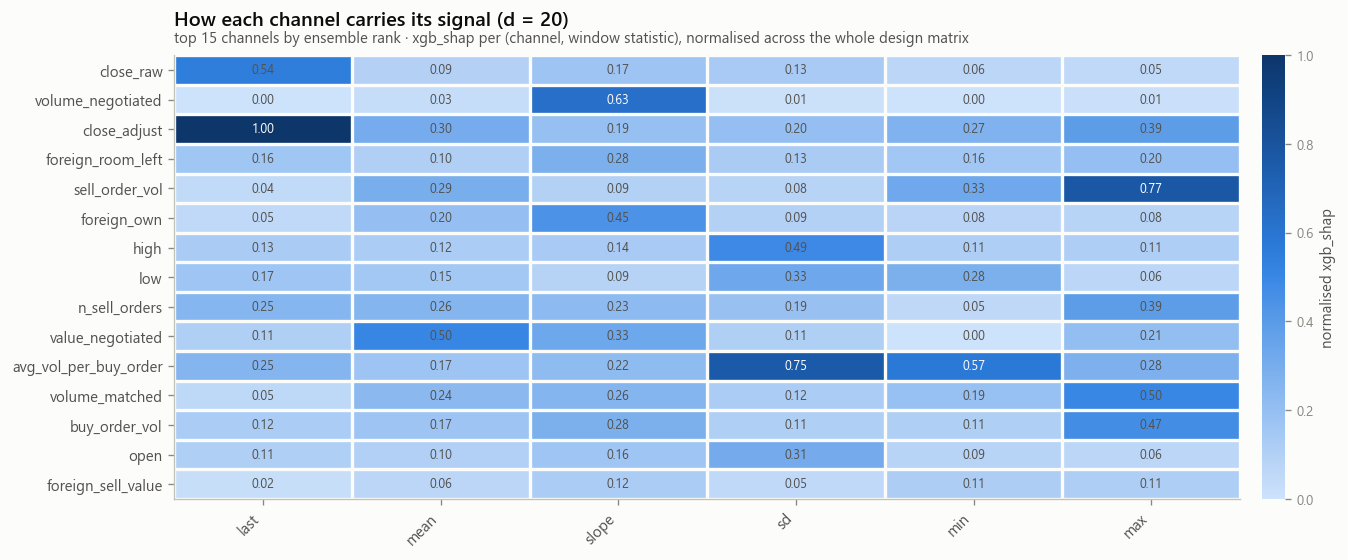

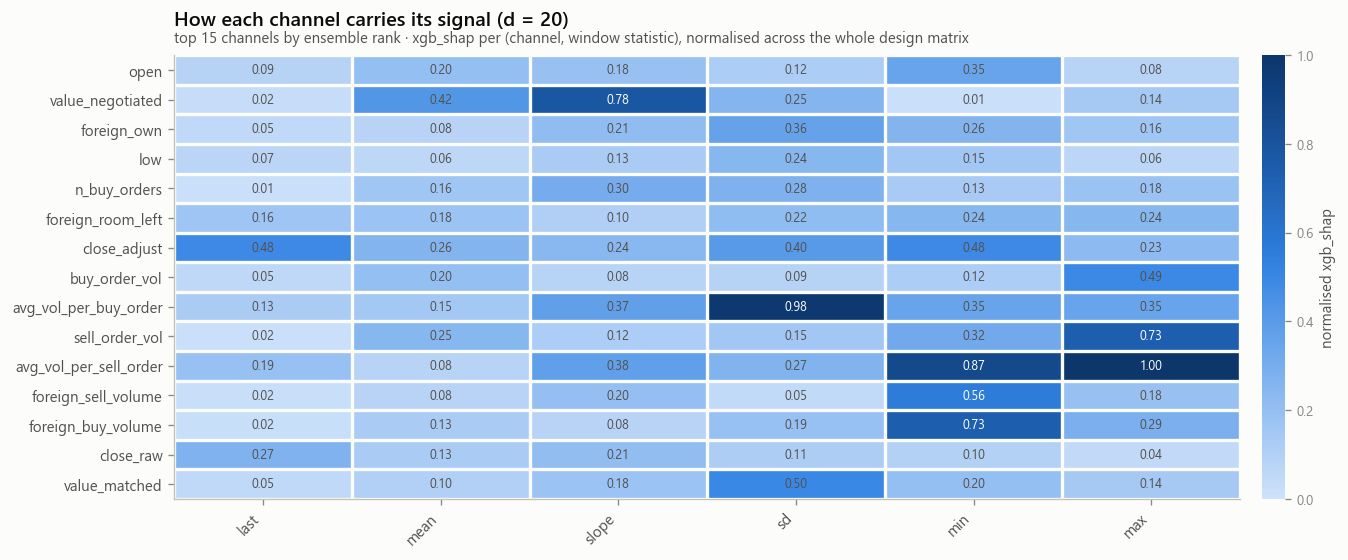

,h=5,h=10
avg_vol_per_buy_order,sd,sd
avg_vol_per_sell_order,min,max
buy_order_vol,max,max
close_adjust,last,min
close_raw,last,last
foreign_buy_value,last,slope
foreign_buy_volume,min,min
foreign_net_value,sd,sd
foreign_net_volume,min,min
foreign_own,slope,sd


In [7]:
for label, result in results.items():
    plots.plot_stat_profile(result, method="xgb_shap", top=15)
    plt.show()

best = pd.DataFrame({
    label: result.best_stat["xgb_shap"] for label, result in results.items()
})
best

## Where the methods agree

Read **across** a row: each column is min-max normalised, so the numbers compare
within a method, not between them. Scores are the MAX over a channel's six
statistics — "is there any view of this window that carries signal".

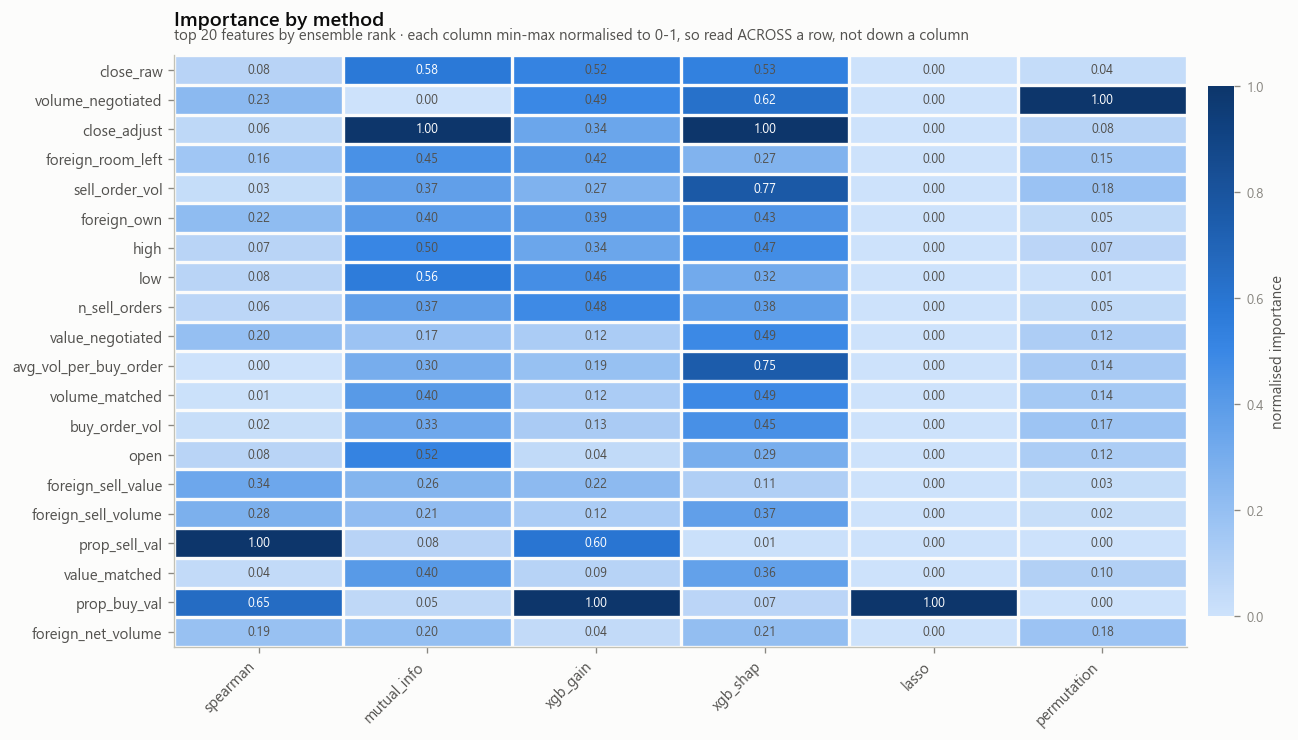

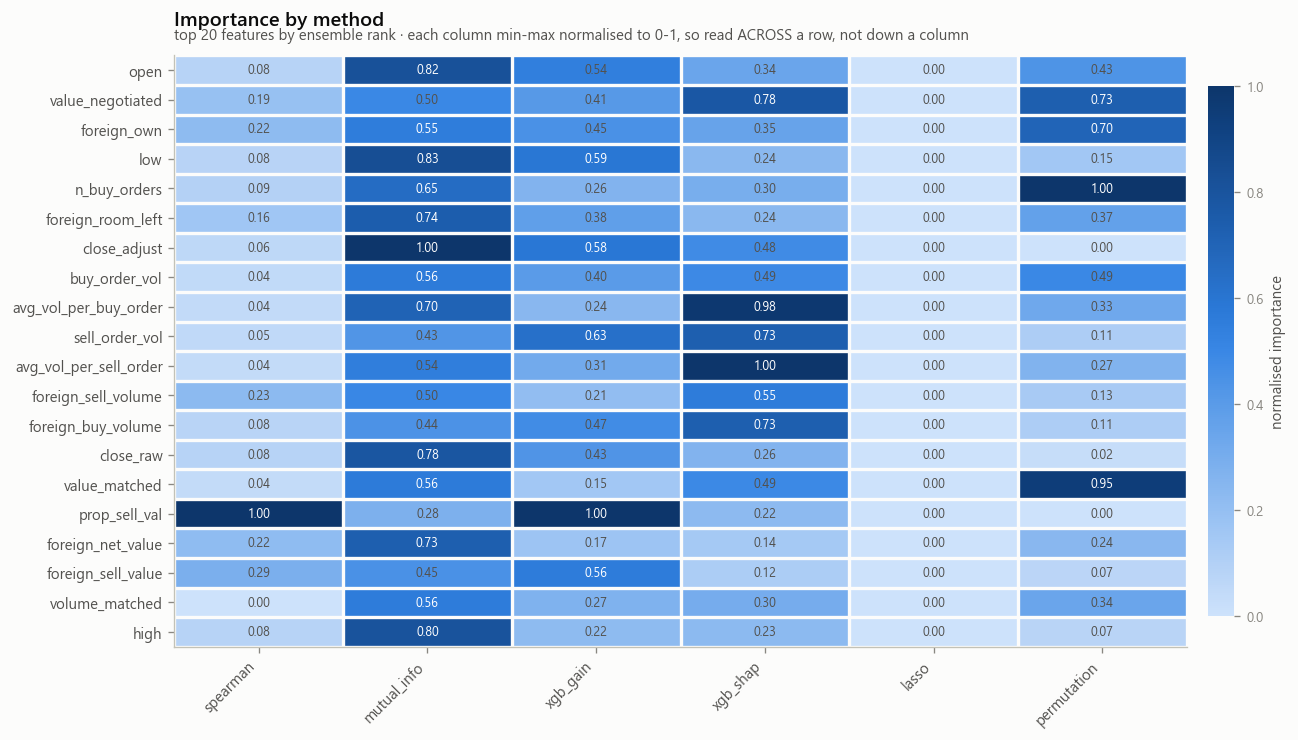

In [8]:
for label, result in results.items():
    plots.plot_method_heatmap(result.scores, top=20)
    plt.show()

## Redundancy

Computed on the **channel** panel, not the design matrix — the model reads a whole
channel or none of it, so dropping `close` at lag 3 while keeping it at lag 4
would be meaningless.

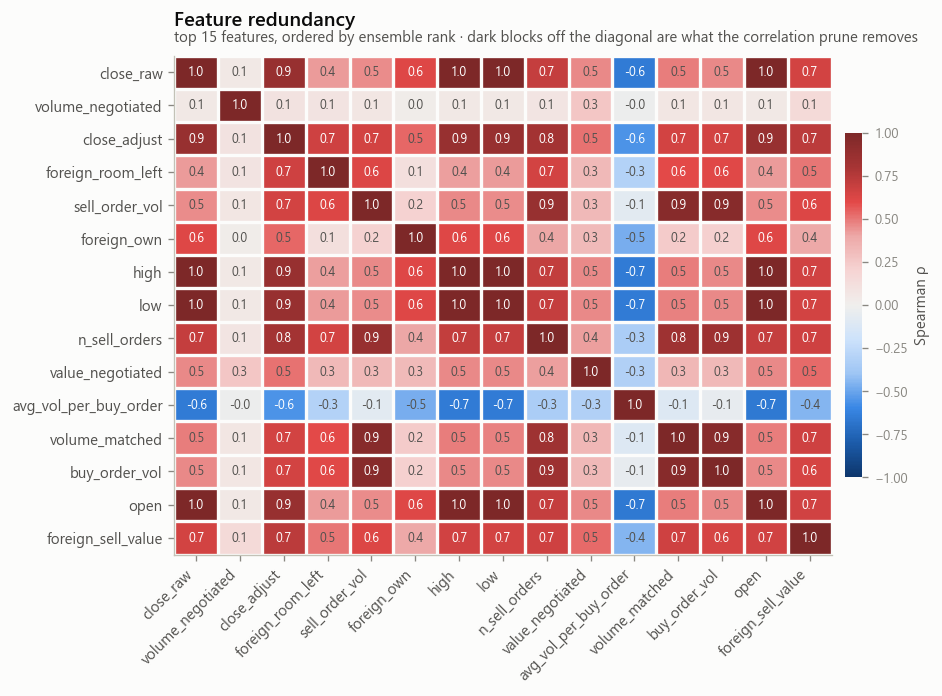

,horizon,dropped,duplicates,spearman
0,h=5,high,close_raw,1.000
1,h=5,low,close_raw,0.999
2,h=5,volume_matched,sell_order_vol,0.947
3,h=5,buy_order_vol,sell_order_vol,0.949
4,h=5,open,close_raw,0.999
5,h=5,foreign_sell_volume,foreign_sell_value,0.941
6,h=5,value_matched,n_sell_orders,0.916
7,h=10,low,open,1.000
8,h=10,sell_order_vol,buy_order_vol,0.949
9,h=10,close_raw,open,0.999


In [9]:
plots.plot_correlation_heatmap(results[f"h={HORIZONS[0]}"].corr, top=15)
plt.show()

redundancy = pd.DataFrame([
    {"horizon": label, "dropped": k, "duplicates": v,
     "spearman": round(float(result.corr.loc[k, v]), 3)}
    for label, result in results.items()
    for k, v in result.dropped_correlated.items()
])
redundancy

## Stability across folds

Each column is one expanding training window. A channel ranked 2nd in the first
fold and 40th since is a regime, not a feature.

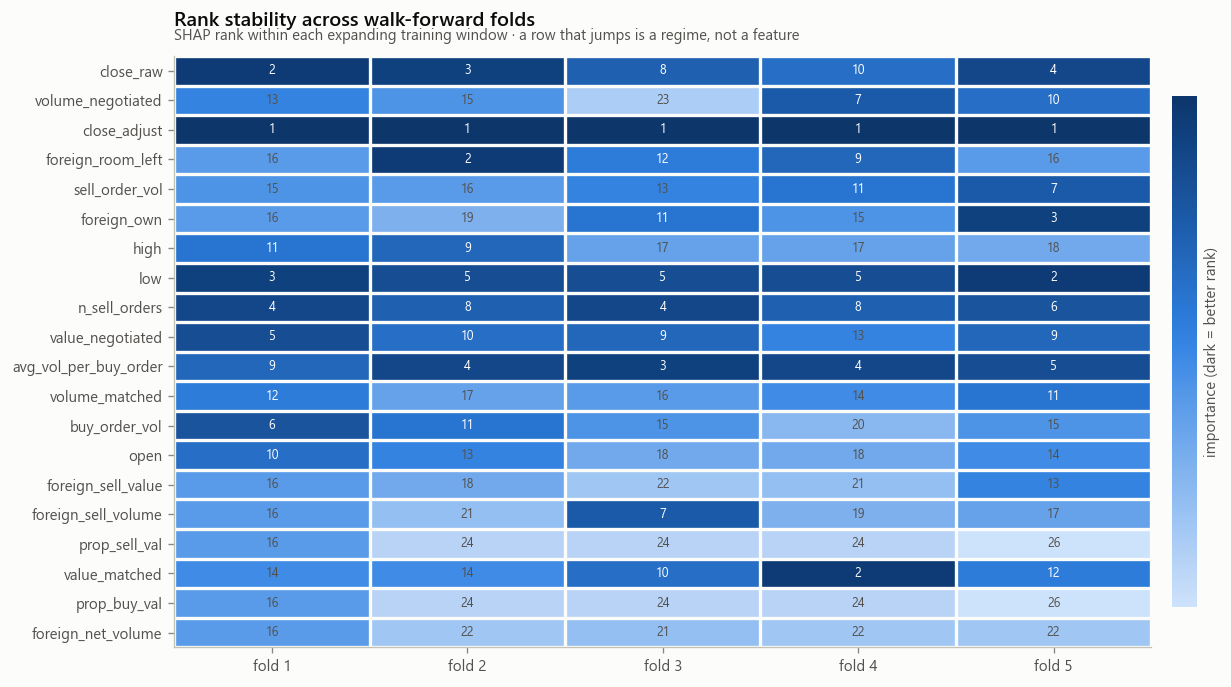

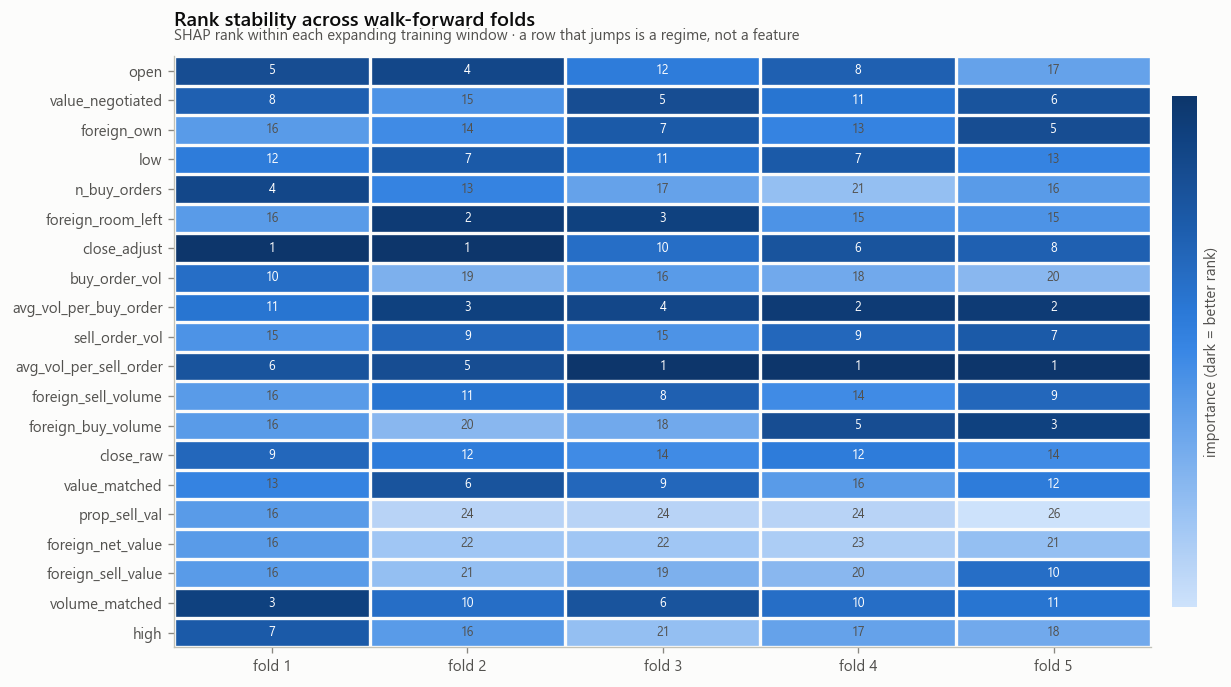

In [10]:
for label, result in results.items():
    plots.plot_stability_heatmap(result.stability, top=20)
    plt.show()

## The kept set

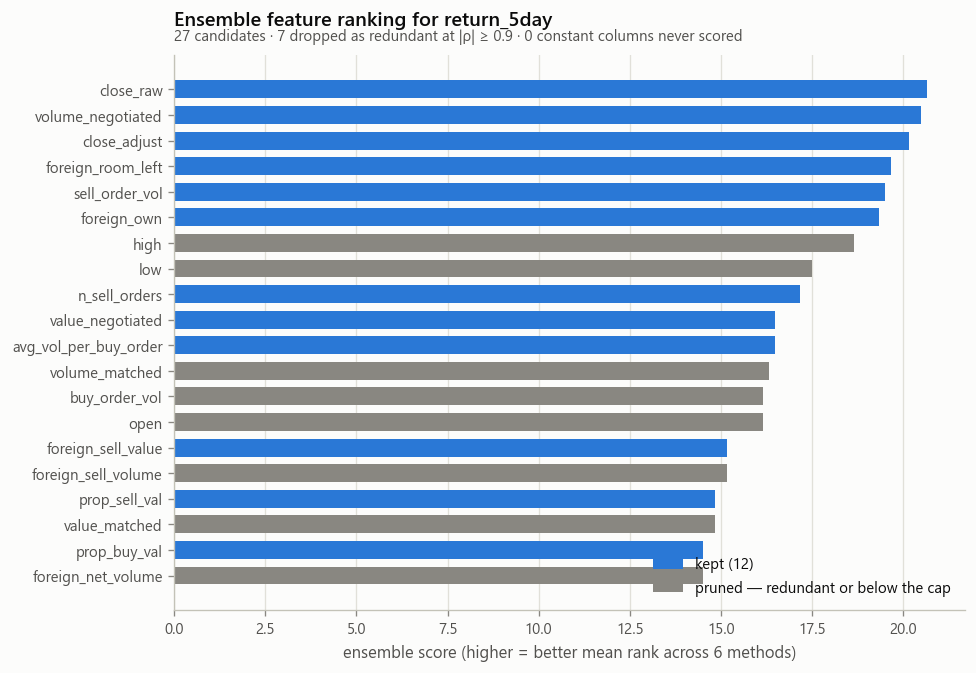

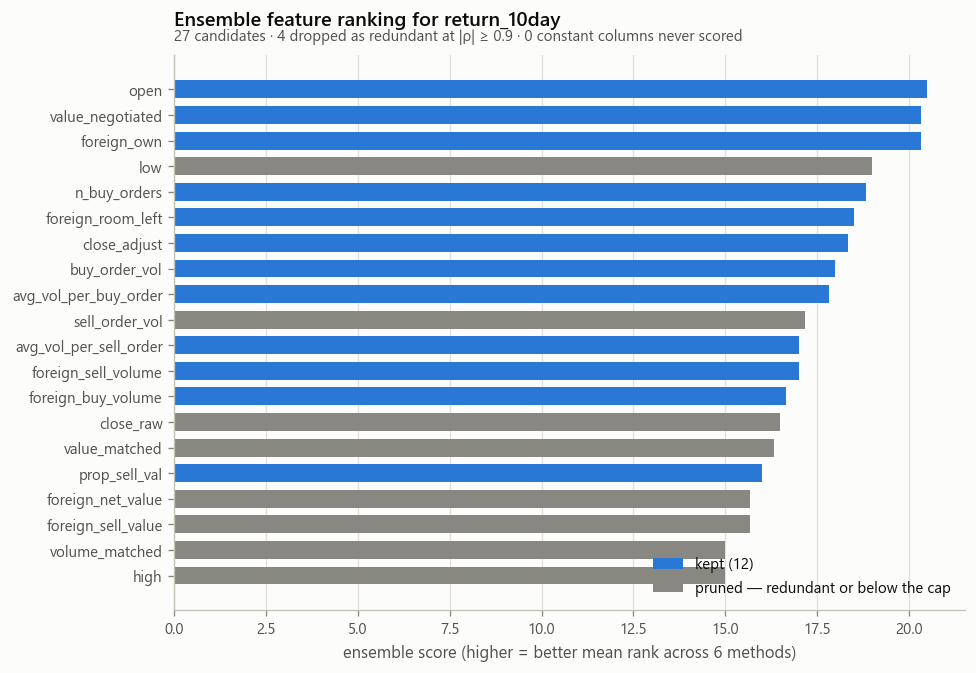

In [11]:
for label, result in results.items():
    plots.plot_ensemble_ranking(result, top=20)
    plt.show()

## Does it generalise?

`ic` — Spearman rank correlation of prediction against realised return — is the
metric to read, per fold. `r2` is reported and will be deeply negative; that is
the honest answer for a level forecast of a near-noise series, not a bug.

⚠️ With a `d`-day window and an `h`-day label, consecutive samples share `d−1`
input days *and* `h−1` label days. The effective sample is far below the row
count, so the **fold spread is the uncertainty** — a mean on its own would present
noise as a result.

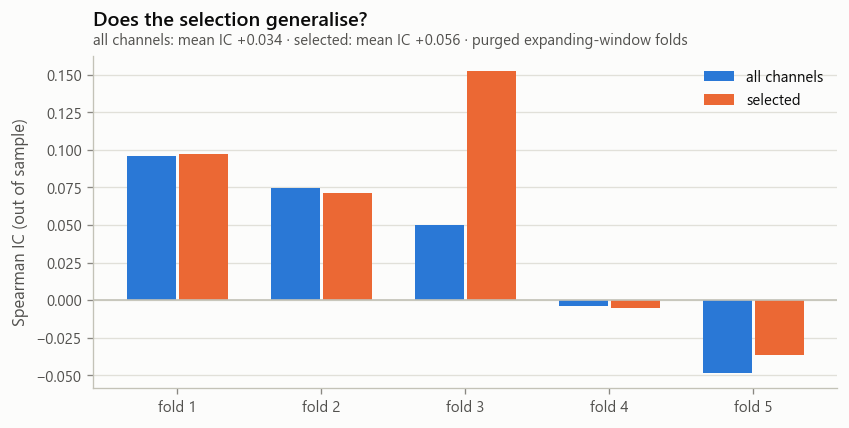

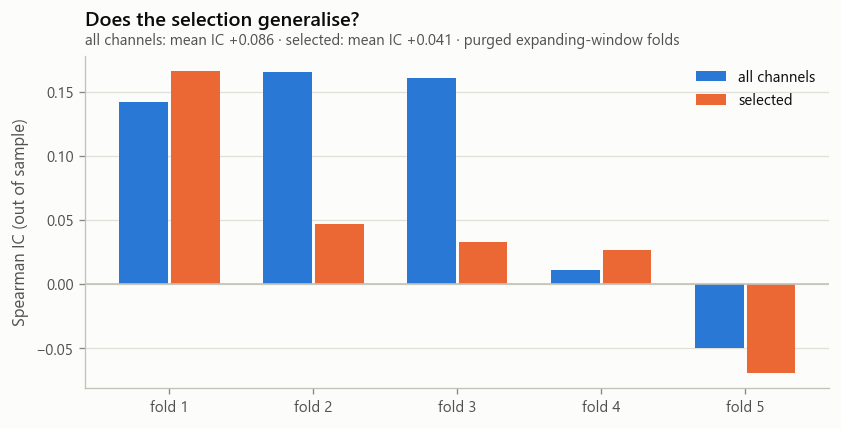

ic                              r2                         hit_rate                        
                        mean     std     min     max    mean     std     min     max     mean     std     min     max
horizon feature_set                                                                                                  
h=10    all channels  0.0858  0.0990 -0.0501  0.1653 -1.0210  0.5224 -1.5702 -0.2868   0.4732  0.0421  0.4054  0.5211
        selected      0.0407  0.0840 -0.0695  0.1664 -1.0300  0.5292 -1.6977 -0.4221   0.4602  0.0472  0.4109  0.5306
h=5     all channels  0.0335  0.0593 -0.0487  0.0962 -1.1196  0.7066 -2.2317 -0.4300   0.4752  0.0337  0.4261  0.5102
        selected      0.0559  0.0767 -0.0365  0.1526 -1.1853  0.6781 -1.9732 -0.5161   0.4771  0.0383  0.4233  0.5305

In [12]:
for label, result in results.items():
    plots.plot_validation(result.validation)
    plt.show()

validation = pd.concat(
    [r.validation.assign(horizon=label) for label, r in results.items()]
)
summary = (
    validation.groupby(["horizon", "feature_set"])[["ic", "r2", "hit_rate"]]
    .agg(["mean", "std", "min", "max"]).round(4)
)
summary

## Do the two horizons agree?

The useful question is not which horizon scores higher — it is whether they
**rise and fall together**. Two horizons whose fold ICs move in step are reading
one slow effect; two that disagree fold by fold are reading noise.

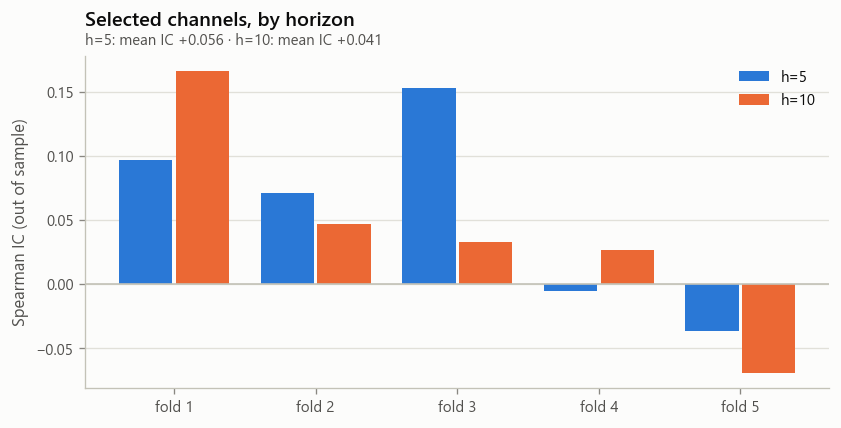

shared 6 of 12: ['avg_vol_per_buy_order', 'close_adjust', 'foreign_own', 'foreign_room_left', 'prop_sell_val', 'value_negotiated']
  only h=5: ['close_raw', 'foreign_sell_value', 'n_sell_orders', 'prop_buy_val', 'sell_order_vol', 'volume_negotiated']
  only h=10: ['avg_vol_per_sell_order', 'buy_order_vol', 'foreign_buy_volume', 'foreign_sell_volume', 'n_buy_orders', 'open']


,channel,h=5,h=10,in_both
0,avg_vol_per_buy_order,True,True,True
1,avg_vol_per_sell_order,False,True,False
2,buy_order_vol,False,True,False
3,close_adjust,True,True,True
4,close_raw,True,False,False
5,foreign_buy_volume,False,True,False
6,foreign_own,True,True,True
7,foreign_room_left,True,True,True
8,foreign_sell_value,True,False,False
9,foreign_sell_volume,False,True,False


In [13]:
plots.plot_horizon_comparison(results)
plt.show()

sets = {label: set(r.kept) for label, r in results.items()}
labels = list(sets)
shared = set.intersection(*sets.values())
agreement = pd.DataFrame({
    "channel": sorted(set.union(*sets.values())),
}).assign(**{
    label: lambda d, s=sets[label]: d["channel"].isin(s) for label in labels
})
agreement["in_both"] = agreement["channel"].isin(shared)
print(f"shared {len(shared)} of {MAX_FEATURES}: {sorted(shared)}")
for label in labels:
    print(f"  only {label}: {sorted(sets[label] - shared)}")
agreement

### Where the time went

In [14]:
timings = pd.concat(
    [r.timing_table.assign(horizon=label) for label, r in results.items()]
).round(3)
timings

,step,seconds,device,share,horizon
0,mutual_info,13.641,cpu,0.325,h=5
1,permutation,11.848,cpu,0.282,h=5
2,validation,8.159,cpu,0.194,h=5
3,stability,5.383,cpu,0.128,h=5
4,lasso,1.391,cpu,0.033,h=5
5,xgb gain + shap,1.333,cpu,0.032,h=5
6,window design,0.174,cpu,0.004,h=5
7,spearman vs target,0.085,cpu,0.002,h=5
8,channel corr matrix,0.012,cpu,0.000,h=5
0,permutation,10.566,cpu,0.372,h=10


## Reading this run

Fill in from the output above — the numbers move whenever the pools are rebuilt.
In order:

1. **The fold ICs, both horizons.** If they are positive in the early folds and
   negative in the last, the relationship has decayed — which is the opposite of
   something to trade, whatever the mean says.
2. **The agreement table.** Channels kept at *both* horizons are the only ones
   worth carrying into a sequence model; a channel that appears at one horizon
   only is a coin flip between "horizon-specific effect" and "noise".
3. **The stat profile.** A channel carried by `last` alone is a level, and a level
   is a proxy for the date on a seventeen-year panel. A channel carried by `slope`
   or `sd` is saying something about the *window*, which is the thing a sequence
   model is there to read.

## Before this feeds a model

⚠️ **Normalisation has to be decided here, not later.** Whatever the sequence model
eats — per-window z-score, divide-by-last-close, differences — the selection must
run on that same representation, or you have selected features for a different
problem. Run today on raw levels, the `last` statistic ranks a channel by how well
its level identifies the era.

⚠️ **`selector.py` is regression-only.** A binary target would be treated as a
continuous label and the numbers would still look plausible.